Simulation examples for validation chapter


In [1]:
import time
import pymc as pm
import arviz as az
from scipy.stats import (
    norm
)
from scipy.optimize import minimize

from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path

IMAGE_DIR = Path('../../book/book/images')

In [2]:
sample_size = 1000

# set up numpy random state
random_state = np.random.default_rng(42)

# True population parameters (using standard normal)
true_mean = 0
true_sd = 1

# take sample
normal_samples = norm.rvs(loc=true_mean, scale=true_sd, size=sample_size, random_state=random_state)

# pop sd is the standard deviation of the entire population (ddof=0)
pop_sd = np.std(normal_samples, ddof=0)
sample_sd = np.std(normal_samples)
sample_mean = np.mean(normal_samples)


In [3]:
# compute confidence interval using t distribution
from scipy.stats import t

# Calculate 95% confidence interval
confidence_level = 0.95
alpha = 1 - confidence_level
degrees_of_freedom = sample_size - 1

# Get the critical t-value
t_critical = t.ppf(1 - alpha/2, degrees_of_freedom)

# Calculate standard error
standard_error = sample_sd / np.sqrt(sample_size)

# Calculate margin of error
margin_of_error = t_critical * standard_error

# Calculate confidence interval
ci_lower = sample_mean - margin_of_error
ci_upper = sample_mean + margin_of_error

print(f"Sample mean: {sample_mean:.5f}")
print(f"Sample SD: {sample_sd:.5f}")
print(f"Standard error: {standard_error:.5f}")
print(f"t-critical value (df={degrees_of_freedom}): {t_critical:.5f}")
print(f"95% Confidence Interval: [{ci_lower:.5f}, {ci_upper:.5f}]")

Sample mean: -0.02889
Sample SD: 0.98872
Standard error: 0.03127
t-critical value (df=999): 1.96234
95% Confidence Interval: [-0.09025, 0.03246]


In [4]:
# do a grid search for mean and sd to find best fit
def normal_params_grid_search(data, mean_grid=None, sd_grid=None):
    if mean_grid is None:
        mean_grid = np.linspace(-1, 1, 1000)
    if sd_grid is None:
        sd_grid = np.linspace(0.5, 1.5, 1000)

    log_likelihoods = np.zeros((len(mean_grid), len(sd_grid)))
    for i, mu in enumerate(mean_grid):
        for j, sd in enumerate(sd_grid):
            # compute log likelihood for current mu and sd
            log_likelihoods[i, j] = norm.logpdf(data, loc=mu, scale=sd).sum()


    # find the parameters that maximize the log likelihood
    max_idx = np.unravel_index(np.argmax(log_likelihoods), log_likelihoods.shape)
    best_mean = mean_grid[max_idx[0]]
    best_sd = sd_grid[max_idx[1]]

    return best_mean, best_sd, log_likelihoods, mean_grid, sd_grid

start_time = time.time()
best_mean, best_sd, log_likelihoods, mean_grid, sd_grid = normal_params_grid_search(normal_samples)
elapsed_time_grid = time.time() - start_time




In [5]:
best_fit_ll = norm.logpdf(normal_samples, loc=best_mean, scale=best_sd).sum()
pop_sd = np.std(normal_samples, ddof=0)
sample_ll = norm.logpdf(normal_samples, loc=sample_mean, 
    scale=pop_sd).sum()

print(f"Execution time: {elapsed_time_grid:.4f} seconds")
#print(f'Execution time versus closed form: {elapsed_time_grid/elapsed_time_cf} times slower')
print(f"Best fit mean: {best_mean:0.4f}, Best fit sd: {best_sd:0.4f}, loglik: {best_fit_ll:0.4f}")
print(f"Sample mean: {sample_mean:0.4f}, Population sd: {pop_sd:0.4f}, loglik: {sample_ll:0.4f}")


Execution time: 24.4162 seconds
Best fit mean: -0.0290, Best fit sd: 0.9885, loglik: -1407.5969
Sample mean: -0.0289, Population sd: 0.9887, loglik: -1407.5968


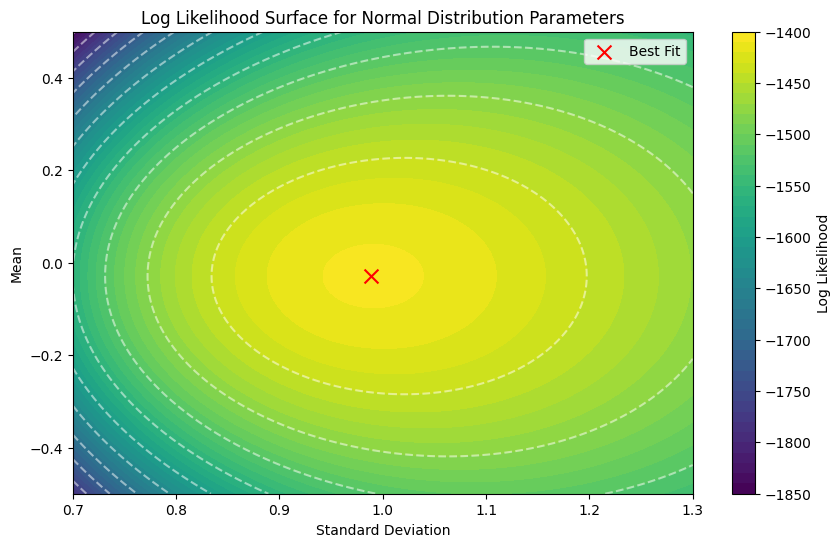

In [6]:
# plot the log likelihood surface using a broader range of values
mean_grid = np.linspace(-.5, .5, 1000)
sd_grid = np.linspace(0.7, 1.3, 1000)
best_mean_vis, best_sd_vis, log_likelihoods_vis, mean_grid, sd_grid = normal_params_grid_search(normal_samples, mean_grid=mean_grid, sd_grid=sd_grid)

plt.figure(figsize=(10, 6))
X, Y = np.meshgrid(sd_grid, mean_grid)
plt.contourf(X, Y, log_likelihoods_vis, levels=50, cmap='viridis')
plt.colorbar(label='Log Likelihood')
plt.scatter(best_sd_vis, best_mean_vis, color='red', label='Best Fit', marker='x', s=100)
plt.xlabel('Standard Deviation')
plt.ylabel('Mean')
plt.title('Log Likelihood Surface for Normal Distribution Parameters')
plt.legend()
# add contour lines
plt.contour(X, Y, log_likelihoods_vis, levels=10, colors='white', alpha=0.5)
plt.savefig(IMAGE_DIR / 'normal_log_likelihood_surface.png', dpi=150, bbox_inches='tight')
plt.show()


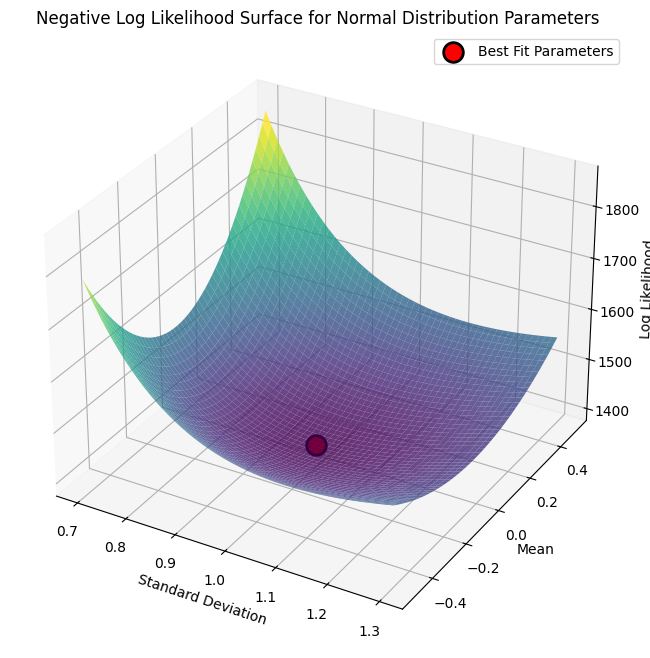

In [7]:
# generate a surface plot of the log likelihoods
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
X, Y = np.meshgrid(sd_grid, mean_grid)
ax.plot_surface(X, Y, -1*log_likelihoods_vis, cmap='viridis', edgecolor='none', alpha=0.8)
ax.set_xlabel('Standard Deviation')
ax.set_ylabel('Mean')
ax.set_zlabel('Log Likelihood')
ax.set_title('Negative Log Likelihood Surface for Normal Distribution Parameters')
# add contour lines on the bottom plane
ax.contour(X, Y, -1* log_likelihoods_vis, zdir='z', offset=np.min(log_likelihoods_vis), levels=10, colors='blue', alpha=0.5)
# add a point on the bottom plane showing best fit parameter values
ax.scatter(best_sd_vis, best_mean_vis, np.min(-1*log_likelihoods_vis), color='red', s=200, marker='o', edgecolors='black', linewidths=2, label='Best Fit Parameters', zorder=10)
ax.legend()

plt.savefig(IMAGE_DIR / 'normal_log_likelihood_surface_3d.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:
# use optimization to find best fit parameters

def negative_log_likelihood(params, data):
    """Negative log likelihood function to minimize"""
    mu, sd = params
    # ensure sd is positive to avoid dividing by zero    
    if sd <= 0:  # ensure sd is positive
        return np.inf
    return -norm.logpdf(data, loc=mu, scale=sd).sum()

# initial guess
initial_params = [0, 1]

start_time = time.time()
result = minimize(negative_log_likelihood, initial_params, args=(normal_samples,), 
                  method='Nelder-Mead')
elapsed_time_opt = time.time() - start_time

opt_mean, opt_sd = result.x
opt_ll = -result.fun

print(f"Optimization time: {elapsed_time_opt:.4f} seconds")
#print(f'Optimization time versus grid search: {elapsed_time_grid/elapsed_time_opt:.4f} times faster')
#print(f'Optimization time versus closed form: {elapsed_time_opt/elapsed_time_cf:.4f} times slower')
print(f"Optimized mean: {opt_mean:0.5f}, Optimized sd: {opt_sd:0.5f}, loglik: {opt_ll:0.5f}")
print(f"Sample mean: {sample_mean:0.5f}, Population sd: {pop_sd:0.5f}, loglik: {sample_ll:0.5f}")


Optimization time: 0.0113 seconds
Optimized mean: -0.02889, Optimized sd: 0.98874, loglik: -1407.59681
Sample mean: -0.02889, Population sd: 0.98872, loglik: -1407.59681


In [9]:
# use really bad initial guesses
initial_params = [10000, 10000]

start_time = time.time()
result = minimize(negative_log_likelihood, initial_params, args=(normal_samples,), 
                  method='Nelder-Mead')
elapsed_time_opt_bad = time.time() - start_time

opt_mean, opt_sd = result.x
opt_ll = -result.fun

print(f"Optimization time: {elapsed_time_opt_bad:.4f} seconds")
#print(f'Optimization time versus grid search: {elapsed_time_grid/elapsed_time_opt_bad:.4f} times faster')
#print(f'Optimization time versus closed form: {elapsed_time_opt_bad/elapsed_time_cf:.4f} times slower')
print(f"Optimized mean: {opt_mean:0.5f}, Optimized sd: {opt_sd:0.5f}, loglik: {opt_ll:0.5f}")
print(f"Sample mean: {sample_mean:0.5f}, Population sd: {pop_sd:0.5f}, loglik: {sample_ll:0.5f}")


Optimization time: 0.0057 seconds
Optimized mean: -0.02893, Optimized sd: 0.98877, loglik: -1407.59682
Sample mean: -0.02889, Population sd: 0.98872, loglik: -1407.59681


In [10]:
# create a version with boundaries on sd parameter in the optimzation
from scipy.optimize import Bounds

# Define bounds: mean unbounded, sd must be positive
bounds = Bounds(lb=[-np.inf, 1e-6], ub=[np.inf, np.inf])

# use really bad initial guesses
initial_params = [0, 1]

start_time = time.time()
result = minimize(negative_log_likelihood, initial_params, args=(normal_samples,), 
                  method='L-BFGS-B', bounds=bounds)
elapsed_time_opt_bounded = time.time() - start_time

opt_mean, opt_sd = result.x
opt_ll = -result.fun

print(f"Optimization time with bounds: {elapsed_time_opt_bounded:.4f} seconds")
print(f'Optimization time versus grid search: {elapsed_time_grid/elapsed_time_opt_bounded:.4f} times faster')
print(f'Optimization time versus closed form: {elapsed_time_opt_bounded/elapsed_time_cf:.4f} times slower')
print(f"Optimized mean: {opt_mean:0.5f}, Optimized sd: {opt_sd:0.5f}, loglik: {opt_ll:0.5f}")
print(f"Sample mean: {sample_mean:0.5f}, Population sd: {pop_sd:0.5f}, loglik: {sample_ll:0.5f}")

Optimization time with bounds: 0.0020 seconds
Optimization time versus grid search: 12009.9676 times faster


NameError: name 'elapsed_time_cf' is not defined